In [71]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict , Literal,List, Sequence,Annotated

In [72]:
class EmployeeState(TypedDict) :
    name : str
    age: int
    salary : float 
    decision : Literal["standard_hr","forced_hr"]
    result :str

In [73]:
def analyze_employee(state : EmployeeState)->EmployeeState:
 age= state['age']
 salary=state['salary']
 if(age<=30 and salary<=40000):
  state['decision']="standard_hr"
 else:
  state['decision']="forced_hr"
 print(f"le dossierde {state['name']}a été analysé")
 return state

In [74]:
def standard_hr_process(state:EmployeeState):
    state['result'] =f"""le dossier de {state['name']}
    a été traité de manière standard"""
    print("*"*88)
    print(f" le dossier de {state['name']} a été traité de manière standard")
    print(f" Name {state['name']} salary :{state['salary']},age :{state['age']}")

    print("*"*88)

    return state 

In [75]:
def foreced_HR_validation(state:EmployeeState):
    state['result']=f"""le dossier  de {state['name']}
    a été traité de manière forcée"""
    print("="*88)
    print(f" le dossier de {state['name']} a été traité de manière forcée")
    print(f" Name : {state['name']} salary :{state['salary']},age :{state['age']}")

    print("="*88)
    return state

In [76]:
def router(state:EmployeeState):
    return state['decision']

In [77]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyse_node" ,analyze_employee)
workflow.add_node("standard_hr_node",standard_hr_process)
workflow.add_node("forced_hr_node",foreced_HR_validation)
workflow.add_edge(START,"analyse_node")
workflow.add_conditional_edges(
    "analyse_node",router,{
        "standard_hr":"standard_hr_node",
        "forced_hr":"forced_hr_node"
    }
)
workflow.add_edge("standard_hr_node",END)
workflow.add_edge("forced_hr_node",END)

graph = workflow.compile()

In [78]:
from IPython.display import Image

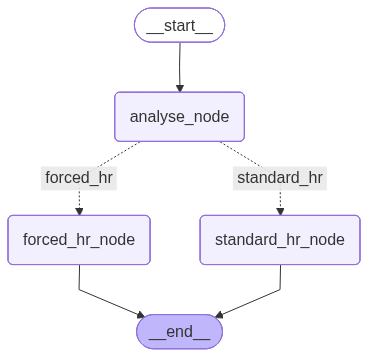

In [79]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
result = graph.invoke({
    "name":"Mohamed", "age":24,"salary":20000
})

le dossierde Mohameda été analysé
****************************************************************************************
 le dossier de Mohamed a été traité de manière standard
 Name Mohamed salary :20000,age :24
****************************************************************************************


In [81]:
print(result)

{'name': 'Mohamed', 'age': 24, 'salary': 20000, 'decision': 'standard_hr', 'result': 'le dossier de Mohamed\n    a été traité de manière standard'}


In [82]:
result = graph.invoke({
    "name":"hanane", "age":35,"salary":30000
})

le dossierde hananea été analysé
 le dossier de hanane a été traité de manière forcée
 Name : hanane salary :30000,age :35


In [83]:
print(result)

{'name': 'hanane', 'age': 35, 'salary': 30000, 'decision': 'forced_hr', 'result': 'le dossier  de hanane\n    a été traité de manière forcée'}


In [84]:
from langchain.tools import tool
from langchain.messages import SystemMessage, AIMessage,ToolMessage,HumanMessage
from langchain_core.messages import BaseMessage,AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from dotenv.ipython import load_dotenv
import os
from langgraph.checkpoint.memory import InMemorySaver

In [85]:
load_dotenv(override=True)

True

In [86]:
@tool
def add(a:float , b :float ):
    """ 
    Add 2 numbers a  and  b
    """
    print(f"Adding {a} to {b}")
    return a+b


@tool
def multiply (a:float , b :float ):
    """ 
    Multiply 2 numbers a  and  b
    """
    print(f"Multiplying {a} and {b}")
    return a*b



@tool
def divide(a:float , b :float ):
    """ 
    Dividing 2 numbers a  by  b
    """
    print(f"Dividing {a} by {b}")
    return a/b
tools = [add,multiply,divide]



In [87]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages ]

In [88]:
llm=  ChatOpenAI(model="gpt-4o",temperature=0)
llm_with_tools=llm.bind_tools(tools=tools)

In [89]:
def assistant(state: AgentState) -> AgentState:
    print("*" * 50)
    print("LLM invoked")
    response = llm_with_tools.invoke(state["messages"])
    # Conserver l’historique et ajouter la réponse
    return {"messages": state["messages"] }


In [90]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage
from typing import TypedDict, List


def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    return "end" if not last_message.tool_calls else "continue"

In [91]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

workflow = StateGraph(AgentState)

workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode(tools=tools))

workflow.set_entry_point("assistant")

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if isinstance(last_message, AIMessage) and getattr(last_message, "tool_calls", None):
        return "continue"
    return "end"
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "end": END,
        "continue": "tools",  # important: continue to tools, not assistant
    }
)

workflow.add_edge("tools", "assistant")
memory=InMemorySaver()
graph = workflow.compile(checkpointer=memory)


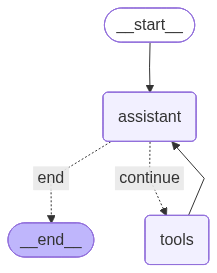

In [92]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))


In [93]:
config = {"configurable": {"thread_id":1}}

resp = graph.invoke(
    {
        "messages": [
            HumanMessage(content="Ajoute 5 à 20 puis multiplie le résultat par 15 et donne-moi un proverbe en arabe")
        ]
    },config=config
)

print(resp["messages"][-1].content)

**************************************************
LLM invoked
Ajoute 5 à 20 puis multiplie le résultat par 15 et donne-moi un proverbe en arabe


In [94]:
print(resp['messages'][-1].content)

Ajoute 5 à 20 puis multiplie le résultat par 15 et donne-moi un proverbe en arabe


In [95]:
resp = graph.invoke(
    {
        "messages": [
            HumanMessage("Bonjour, je m'appelle Malak ")
        ]
    },config =config
)
print(resp['messages'][-1].content)


**************************************************
LLM invoked
Bonjour, je m'appelle Malak 


In [96]:
resp = graph.invoke(
    {
        "messages": [
            HumanMessage("Comment je m'appelle ")
        ]
    },config =config
)
print(resp['messages'][-1].content)


**************************************************
LLM invoked
Comment je m'appelle 
